# Dynamic Cobweb Graphs

This notebook builds dynamic cobweb diagrams for one-dimensional maps of the form

$$x_{t+1}=G(x_t).$$

It includes:
- a reusable cobweb plotting function,
- frame-by-frame dynamic cobweb rendering,
- examples for monotone convergence, oscillatory convergence, and instability.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

plt.rcParams['figure.figsize'] = (7, 6)
plt.rcParams['axes.grid'] = True

## 1) Core utilities

In [3]:
def iterate_map(G, x0, n_steps):
    """Return path [x0, x1, ..., x_n]."""
    xs = np.empty(n_steps + 1)
    xs[0] = x0
    for t in range(n_steps):
        xs[t + 1] = G(xs[t])
    return xs


def plot_cobweb(G, x0, n_steps, x_min, x_max, title='Cobweb Diagram', annotate=False):
    """Static cobweb plot for x_{t+1}=G(x_t)."""
    grid = np.linspace(x_min, x_max, 500)
    path = iterate_map(G, x0, n_steps)

    fig, ax = plt.subplots()
    ax.plot(grid, G(grid), lw=2, label='G(x)')
    ax.plot(grid, grid, 'k--', lw=1.5, label='45-degree line')

    # Draw cobweb steps
    x_curr = x0
    for t in range(n_steps):
        x_next = G(x_curr)
        ax.plot([x_curr, x_curr], [x_curr, x_next], color='tab:red', lw=1.8)
        ax.plot([x_curr, x_next], [x_next, x_next], color='tab:red', lw=1.8)
        if annotate:
            ax.scatter([x_curr], [x_curr], color='tab:blue', s=20)
            ax.text(x_curr, x_curr, f'  x_{t}', fontsize=8)
        x_curr = x_next

    ax.scatter([path[0]], [path[0]], color='tab:green', zorder=5, label='x0')
    ax.scatter([path[-1]], [path[-1]], color='tab:purple', zorder=5, label='x_n')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(x_min, x_max)
    ax.set_xlabel('x_t')
    ax.set_ylabel('x_{t+1}')
    ax.set_title(title)
    ax.legend(loc='best')
    plt.show()


def animate_cobweb(G, x0, n_steps, x_min, x_max, title='Dynamic Cobweb'):
    """Return a matplotlib animation object that draws cobweb steps progressively."""
    grid = np.linspace(x_min, x_max, 500)

    fig, ax = plt.subplots()
    ax.plot(grid, G(grid), lw=2, label='G(x)')
    ax.plot(grid, grid, 'k--', lw=1.5, label='45-degree line')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(x_min, x_max)
    ax.set_xlabel('x_t')
    ax.set_ylabel('x_{t+1}')
    ax.set_title(title)

    # Lines for cobweb segments
    lines = []
    for _ in range(2 * n_steps):
        line, = ax.plot([], [], color='tab:red', lw=2)
        lines.append(line)

    dot, = ax.plot([], [], 'o', color='tab:blue')

    path = iterate_map(G, x0, n_steps)

    def init():
        for ln in lines:
            ln.set_data([], [])
        dot.set_data([], [])
        return lines + [dot]

    def update(frame):
        # frame=0..2*n_steps
        for ln in lines:
            ln.set_data([], [])

        x_curr = x0
        seg = 0
        for t in range(n_steps):
            x_next = G(x_curr)
            if seg < frame:
                lines[seg].set_data([x_curr, x_curr], [x_curr, x_next])
            seg += 1
            if seg < frame:
                lines[seg].set_data([x_curr, x_next], [x_next, x_next])
            seg += 1
            x_curr = x_next

        # Current point marker
        idx = min(frame // 2, n_steps)
        dot.set_data([path[idx]], [path[idx]])
        return lines + [dot]

    ani = FuncAnimation(fig, update, frames=2 * n_steps + 1, init_func=init, interval=450, blit=True)
    ax.legend(loc='best')
    plt.close(fig)
    return ani

## 2) Case A: Monotone convergence (Solow-style increasing map)

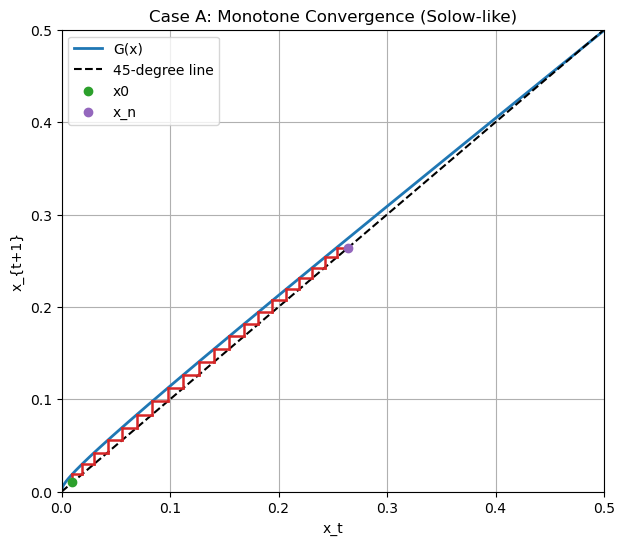

In [10]:
# Solow-like map: G(k) = (1-delta)k + s k^alpha
alpha = 0.35
s = 0.05
delta = 0.08

def G_solow(k):
    k = np.maximum(k, 1e-12)
    return (1 - delta) * k + s * k**alpha

plot_cobweb(G_solow, x0=0.01, n_steps=20, x_min=0.0, x_max=0.5,
            title='Case A: Monotone Convergence (Solow-like)')

## 3) Case B: Damped oscillation ($-1 < G'(x^*) < 0$)

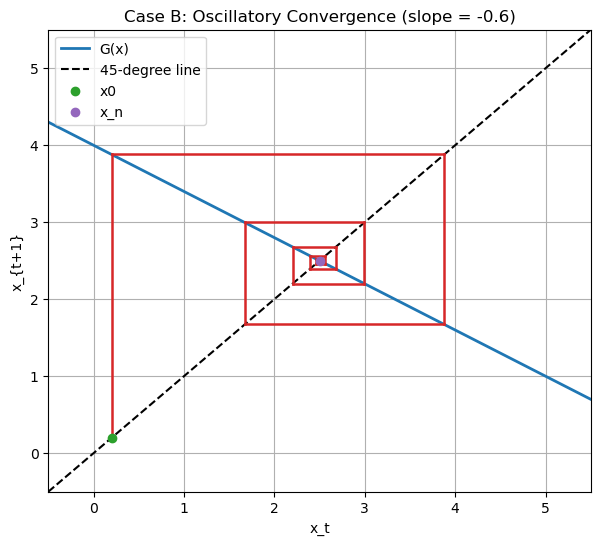

In [11]:
x_star = 2.5
b = 0.6

# Linear map around fixed point with negative slope: G(x)=x* - b(x-x*)
def G_osc(x):
    return x_star - b * (x - x_star)

plot_cobweb(G_osc, x0=0.2, n_steps=15, x_min=-0.5, x_max=5.5,
            title='Case B: Oscillatory Convergence (slope = -0.6)')

## 4) Case C: Divergence ($|G'(x^*)|>1$)

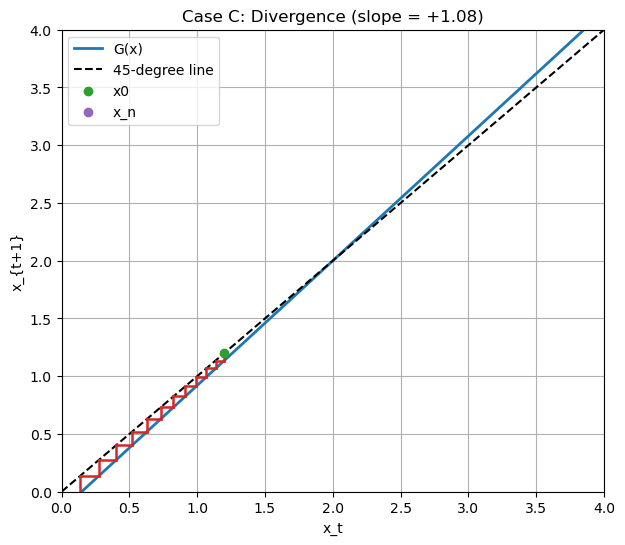

In [12]:
x_star = 2.0
m = 1.08

def G_div(x):
    return x_star + m * (x - x_star)

plot_cobweb(G_div, x0=1.2, n_steps=14, x_min=0.0, x_max=4.0,
            title='Case C: Divergence (slope = +1.08)')

## 5) Dynamic (animated) cobweb examples

Run one of the cells below to render an animation inline.

In [ ]:
from IPython.display import HTML

ani1 = animate_cobweb(G_solow, x0=0.01, n_steps=18, x_min=0.0, x_max=1.0,
                     title='Dynamic Cobweb: Monotone Convergence')
HTML(ani1.to_jshtml())

In [ ]:
ani2 = animate_cobweb(G_osc, x0=0.2, n_steps=14, x_min=-0.5, x_max=5.5,
                     title='Dynamic Cobweb: Oscillatory Convergence')
HTML(ani2.to_jshtml())

## 6) Optional: save animation to GIF (requires pillow)

In [ ]:
# Uncomment to save:
# ani1.save('cobweb_monotone.gif', writer='pillow', fps=2)
# ani2.save('cobweb_oscillatory.gif', writer='pillow', fps=2)